# Week 2 · Distribution Shape, Missing Data, Outliers & Transformations
*DS 207 · Week 2*

This week develops the diagnostic toolkit needed before any dataset can be trusted for modeling: reading the shape of a distribution, testing it against the assumption of normality, handling missing values without introducing bias, detecting and treating outliers, and applying transformations that make skewed data well-behaved. Every technique is applied to a single running dataset so that the diagnosis-to-treatment pipeline reads as one continuous decision process rather than five disconnected exercises.

EC Corro, built in collaboration with Claude, ChatGPT, and Gemini.

## Learning Objectives

- Diagnose distribution shape using histograms, skewness, and excess kurtosis, and explain what each statistic implies about the data-generating process.
- Test whether a variable can reasonably be treated as normally distributed using visual checks (histogram, Q-Q plot) and statistical checks (Shapiro-Wilk, skewness/kurtosis rules of thumb).
- Classify a missingness pattern as MCAR, MAR, or MNAR and select an appropriate treatment strategy (drop vs. impute) with justification.
- Detect outliers using the IQR method and the z-score method, and decide when a flagged point should be investigated, corrected, or retained.
- Apply log, square-root, and standardization transformations appropriately, and explain why standardization alone does not fix skewness.

## Prerequisites

Week 1 (descriptive statistics: measures of central tendency, spread, and levels of measurement) and basic familiarity with pandas and numpy.

## Business Context

BayaniFund Microfinance is a Cebu-based lending fintech that serves small borrowers who are underserved by traditional banks — market vendors, tricycle operators, sari-sari store owners, and salaried employees at small local firms. RJ Bautista, BayaniFund's Head of Credit Risk, is preparing applicant monthly income data to feed into an automated credit-scoring model. Before that can happen safely, RJ needs answers to a chain of questions:

- Is income normally distributed, or does it need special handling?
- Why are some applications missing an income figure, and is it safe to simply drop them?
- Which reported incomes are genuine, and which are data-entry mistakes or fraud attempts?
- Once the data is clean, what transformation puts income on a scale the scoring model can use reliably?

This week's techniques are the pipeline RJ runs on every underwriting cycle.

## Dataset

The dataset below simulates one underwriting batch of BayaniFund loan applications: 400 applicants, their employment type (Formal vs. Informal), months employed or operating their livelihood, requested loan amount, and self-reported monthly income. The generating process deliberately builds in the three problems RJ has to solve this week:

- a right-skewed income distribution,
- income values missing more often for informal-sector applicants, and
- a handful of implausible income entries from data-entry slips and fraud attempts.

The seed is fixed so every run of this notebook reproduces the same batch.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

rng = np.random.default_rng(207)

n = 400

# Employment type mix typical of a microfinance applicant pool
employment_type = rng.choice(["Formal", "Informal"], size=n, p=[0.4, 0.6])

# Monthly income (PHP): lognormal generator produces the right-skewed shape
# typical of income data -- most applicants cluster at modest incomes with a
# long tail of higher earners.
mu = np.where(employment_type == "Formal", np.log(18000), np.log(13000))
sigma = np.where(employment_type == "Formal", 0.35, 0.45)
monthly_income_php = rng.lognormal(mean=mu, sigma=sigma)
monthly_income_php = np.round(monthly_income_php, -1)

months_employed = rng.integers(3, 121, size=n).astype(float)
loan_amount_requested_php = np.round(monthly_income_php * rng.uniform(0.8, 2.5, size=n), -2)
applicant_id = np.array([f"BF{2207 + i:05d}" for i in range(n)])

applicants = pd.DataFrame({
    "applicant_id": applicant_id,
    "employment_type": employment_type,
    "months_employed": months_employed,
    "monthly_income_php": monthly_income_php,
    "loan_amount_requested_php": loan_amount_requested_php,
})

# Missingness: informal-sector applicants are more likely to leave income
# blank because they lack payslips to reference. This is not random -- it
# depends on an observed column (employment_type) -- which we revisit in
# Subtopic 3.
miss_prob = np.where(applicants["employment_type"] == "Informal", 0.32, 0.06)
missing_mask = rng.random(n) < miss_prob
applicants.loc[missing_mask, "monthly_income_php"] = np.nan

# Data quality issues planted for Subtopic 4: a few data-entry slips (an
# extra zero typed in) and a few fraud attempts (implausibly high reported
# income relative to the applicant pool).
non_missing_idx = applicants.index[applicants["monthly_income_php"].notna()]
entry_error_idx = rng.choice(non_missing_idx, size=4, replace=False)
applicants.loc[entry_error_idx, "monthly_income_php"] *= 10

remaining_idx = np.setdiff1d(non_missing_idx, entry_error_idx)
fraud_idx = rng.choice(remaining_idx, size=3, replace=False)
applicants.loc[fraud_idx, "monthly_income_php"] = rng.uniform(280000, 400000, size=3).round(-1)

applicants.head()

,applicant_id,employment_type,months_employed,monthly_income_php,loan_amount_requested_php
0,BF02207,Formal,55.0,165500.0,26500.0
1,BF02208,Informal,5.0,NaN,19800.0
2,BF02209,Informal,72.0,6420.0,8500.0
3,BF02210,Informal,81.0,29440.0,42800.0
4,BF02211,Informal,58.0,NaN,18000.0


### 1. Distribution Shape — Histograms, Skewness, and Kurtosis

**Business Hook:** RJ pulls the average reported income across this batch of applications to summarize it for a lending committee. Before presenting a single number, RJ needs to know whether that average is even a fair description of the data, or whether the distribution's shape makes it misleading.

#### Intuition & Analogy

Picture the income of every applicant as a mark on a number line, then imagine those marks piling up like sand into dunes.

- **Symmetric distribution:** one neat dune, evenly sloped on both sides — the mean sits right at the peak.
- **Right (positive) skew:** a dune with a long, thin ridge trailing off to the right — most applicants earn a modest, similar amount, but a smaller number earn far more, stretching the right tail out. This is the single most common shape in income, spending, and loan-amount data.
- **Kurtosis:** a different property — how heavy the tails are and how sharp the peak is compared to a normal distribution. A distribution with heavy tails produces extreme values more often than a normal distribution would predict, exactly the kind of behavior a risk manager needs to anticipate before extreme values get treated as routine.

#### Theory — By Hand

For a sample $x_1, \dots, x_n$ with mean $\bar{x}$, define the second, third, and fourth central moments:

$$m_2 = \frac{1}{n}\sum_{i=1}^n (x_i - \bar{x})^2, \qquad m_3 = \frac{1}{n}\sum_{i=1}^n (x_i - \bar{x})^3, \qquad m_4 = \frac{1}{n}\sum_{i=1}^n (x_i - \bar{x})^4$$

The (population) skewness and excess kurtosis are:

$$g_1 = \frac{m_3}{m_2^{3/2}}, \qquad g_2 = \frac{m_4}{m_2^2} - 3$$

A normal distribution has $g_1 = 0$ and $g_2 = 0$. The commonly reported sample-adjusted (Fisher–Pearson) versions are:

$$G_1 = \frac{\sqrt{n(n-1)}}{n-2}\, g_1, \qquad G_2 = \frac{n-1}{(n-2)(n-3)}\big[(n+1)g_2 + 6\big]$$

**Worked example.** Take five hypothetical applicant incomes (PHP): $12{,}000,\ 13{,}000,\ 14{,}000,\ 15{,}000,\ 46{,}000$ — four applicants clustered together and one high earner.

- Mean: $\bar{x} = \dfrac{12000+13000+14000+15000+46000}{5} = 20{,}000$
- Deviations from the mean: $-8000,\ -7000,\ -6000,\ -5000,\ 26000$
- $m_2 = \dfrac{(-8000)^2+(-7000)^2+(-6000)^2+(-5000)^2+(26000)^2}{5} \approx 1.70\times 10^{8}$
- $m_3 = \dfrac{(-8000)^3+(-7000)^3+(-6000)^3+(-5000)^3+(26000)^3}{5} \approx 3.376\times 10^{12}$
- $g_1 = \dfrac{m_3}{m_2^{1.5}} \approx 1.478$, and the adjusted $G_1 = \dfrac{\sqrt{5\cdot 4}}{3}\,(1.478) \approx 2.203$

A positive skewness this large already signals a long right tail from a sample of only five points — exactly the shape RJ expects income data to have, and the reason the mean (20,000) sits well above where four of the five applicants actually are.

#### By Tool

In [2]:
# Verify the by-hand result on the five-point worked example
example = np.array([12000, 13000, 14000, 15000, 46000.0])
print("By-hand check -- mean:", example.mean())
print("By-hand check -- skewness (adjusted, matches G1 above):", stats.skew(example, bias=False))
print("By-hand check -- excess kurtosis (adjusted):", stats.kurtosis(example, bias=False))

By-hand check -- mean: 20000.0
By-hand check -- skewness (adjusted, matches G1 above): 2.2032524114778784
By-hand check -- excess kurtosis (adjusted): 4.882878892733565


n (non-missing) = 311
Mean income   = PHP 21,016
Median income = PHP 15,470
Skewness      = 8.34
Excess kurtosis = 77.22


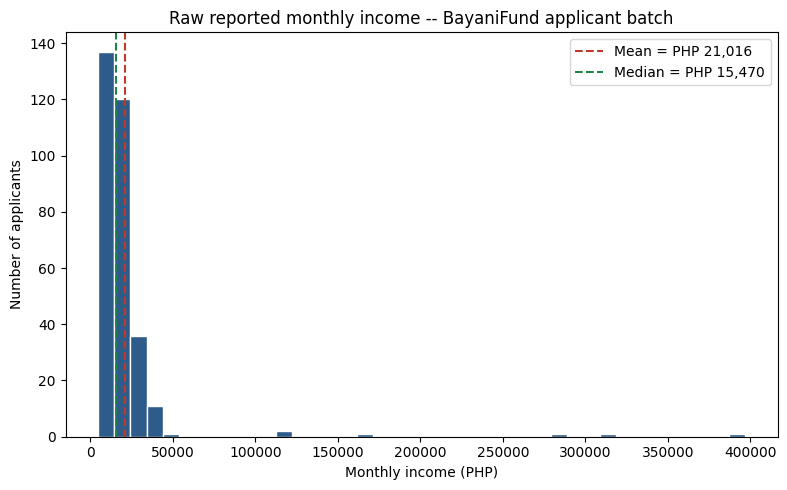

In [3]:
# Now apply the same diagnostics to the full applicant batch (raw, uncleaned)
income_raw = applicants["monthly_income_php"].dropna()

mean_income = income_raw.mean()
median_income = income_raw.median()
skew_raw = stats.skew(income_raw, bias=False)
kurt_raw = stats.kurtosis(income_raw, bias=False)

print(f"n (non-missing) = {len(income_raw)}")
print(f"Mean income   = PHP {mean_income:,.0f}")
print(f"Median income = PHP {median_income:,.0f}")
print(f"Skewness      = {skew_raw:.2f}")
print(f"Excess kurtosis = {kurt_raw:.2f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(income_raw, bins=40, color="#2E5C8A", edgecolor="white")
ax.axvline(mean_income, color="#C0392B", linestyle="--", label=f"Mean = PHP {mean_income:,.0f}")
ax.axvline(median_income, color="#1E8449", linestyle="--", label=f"Median = PHP {median_income:,.0f}")
ax.set_xlabel("Monthly income (PHP)")
ax.set_ylabel("Number of applicants")
ax.set_title("Raw reported monthly income -- BayaniFund applicant batch")
ax.legend()
plt.tight_layout()
plt.show()

The full batch shows a skewness of roughly 8.3 and excess kurtosis above 75 — far beyond what the five-point example suggested and far beyond what an ordinary right-skewed income distribution would produce on its own.

- That gap between "income is naturally a bit skewed" and "skewness of 8.3" is itself a diagnostic clue: a handful of extreme values are inflating both statistics disproportionately, since both $m_3$ and $m_4$ raise deviations to the third and fourth power.
- This is a preview of the outlier problem tackled in Subtopic 4 — shape statistics alone cannot yet tell RJ whether this is inherent to income data or a symptom of bad entries.

#### Business Application

- RJ now has a concrete reason not to lead the credit committee report with the mean: at roughly PHP 21,000, the mean overstates what a typical applicant earns, while the median of roughly PHP 15,500 is a more honest single-number summary given how far skewed the distribution is.
- RJ flags in the report that shape diagnostics must run before any further modeling, since the extremity of the skew and kurtosis signals that outlier and missing-data cleanup — this week's remaining subtopics — has to happen before this income variable is trustworthy input for the credit-scoring model.

### 2. Checking for Normality — Visual and Statistical Checks

**Business Hook:** Several standard credit-scoring approaches (including logistic regression with continuous predictors) behave best when a numeric input is at least approximately symmetric. Before RJ decides whether income needs any correction, RJ needs a defensible way to check whether it can be treated as normally distributed.

#### Intuition & Analogy

Checking for normality is like checking whether a photo is level before you frame it. A quick glance often tells you it's crooked, but a spirit level gives you a number to confirm it and to say by how much.

- **The visual glance — histogram and Q-Q plot:** a Q-Q plot (quantile-quantile plot) lines up the sample's actual values against the values a perfect normal distribution would produce at the same percentiles. If the data is normal, the points fall on a straight diagonal line; any curve away from that line shows exactly where and how the data departs from normality.
- **The spirit level — Shapiro-Wilk test and skewness/kurtosis rules of thumb:** these turn "looks off" into a number and a decision threshold.

#### Theory — By Hand

Two everyday rules of thumb, applied to the skewness ($G_1$) and excess kurtosis ($G_2$) computed in Subtopic 1:

$$SE(G_1) \approx \sqrt{\frac{6}{n}}, \qquad SE(G_2) \approx \sqrt{\frac{24}{n}}$$

$$z_{\text{skew}} = \frac{G_1}{SE(G_1)}, \qquad z_{\text{kurt}} = \frac{G_2}{SE(G_2)}$$

If $|z| > 2$ (roughly a 95% threshold), the departure from normality on that dimension is statistically noticeable rather than sampling noise.

**Worked example**, reusing the five-point income sample from Subtopic 1 ($G_1 \approx 2.203$, $n=5$):

- $SE(G_1) = \sqrt{6/5} \approx 1.095$
- $z_{\text{skew}} = \dfrac{2.203}{1.095} \approx 2.01$

Even with only five observations, the skewness is already at the edge of the conventional threshold — a strong hint from a tiny sample that this batch of incomes is not shaped like a normal distribution. A formal test such as Shapiro-Wilk compares the ordered sample values against the values expected under normality and returns a test statistic $W$ close to 1 for normal-looking data; the further $W$ falls below 1, with a correspondingly small p-value, the stronger the evidence against normality.

#### By Tool

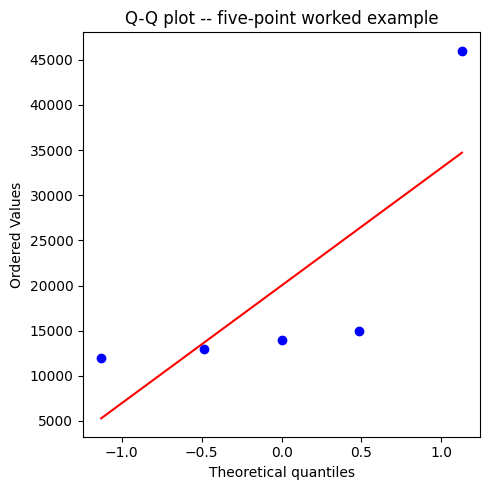

By-hand check -- z_skew = 2.01


In [4]:
# Q-Q plot and the skewness/kurtosis rule of thumb on the five-point example
fig, ax = plt.subplots(figsize=(5, 5))
stats.probplot(example, dist="norm", plot=ax)
ax.set_title("Q-Q plot -- five-point worked example")
plt.tight_layout()
plt.show()

n_ex = len(example)
G1_ex = stats.skew(example, bias=False)
se_skew_ex = np.sqrt(6 / n_ex)
print(f"By-hand check -- z_skew = {G1_ex / se_skew_ex:.2f}")

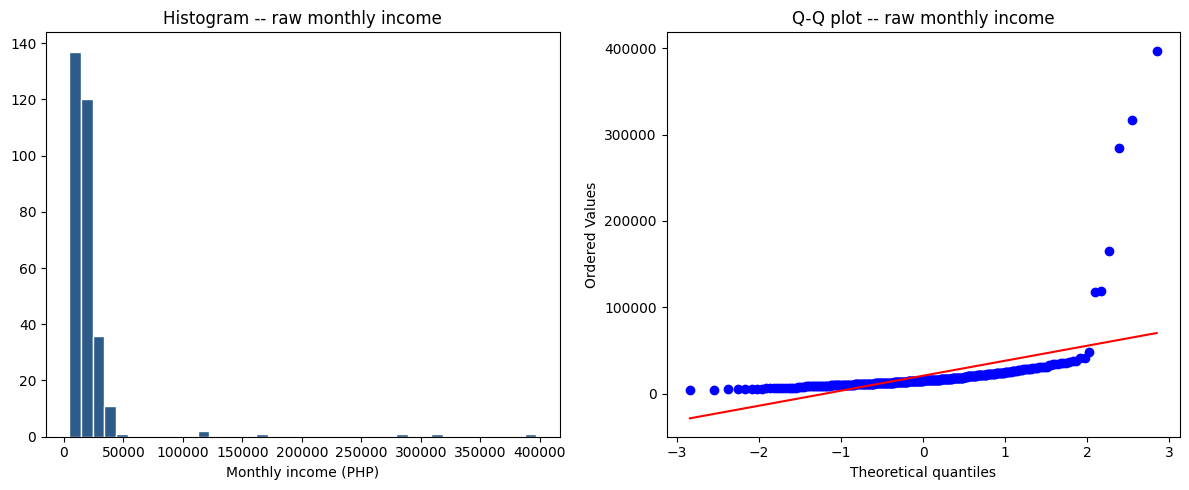

Shapiro-Wilk: W = 0.2637, p = 2.79e-33
z_skew = 60.1, z_kurt = 278.0


In [5]:
# Apply the same checks to the full raw income batch
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(income_raw, bins=40, color="#2E5C8A", edgecolor="white")
axes[0].set_title("Histogram -- raw monthly income")
axes[0].set_xlabel("Monthly income (PHP)")

stats.probplot(income_raw, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q plot -- raw monthly income")

plt.tight_layout()
plt.show()

shapiro_stat, shapiro_p = stats.shapiro(income_raw)
n_full = len(income_raw)
se_skew = np.sqrt(6 / n_full)
se_kurt = np.sqrt(24 / n_full)
z_skew = skew_raw / se_skew
z_kurt = kurt_raw / se_kurt

print(f"Shapiro-Wilk: W = {shapiro_stat:.4f}, p = {shapiro_p:.2e}")
print(f"z_skew = {z_skew:.1f}, z_kurt = {z_kurt:.1f}")

Both checks agree, decisively.

- The Q-Q plot shows the applicant income points curving sharply away from the diagonal at the upper end — the visual signature of a heavy right tail.
- The Shapiro-Wilk statistic is far below 1 with a p-value near zero, and both $z_{\text{skew}}$ and $z_{\text{kurt}}$ are dozens of standard errors away from 0.

Raw income fails every normality check applied to it, and by a wide margin — consistent with the extreme skewness and kurtosis already seen in Subtopic 1.

#### Business Application

- RJ now has documented, defensible evidence — not just a hunch — that raw monthly income cannot go directly into any scoring approach that assumes approximately normal or symmetric inputs.
- This finding is what justifies the transformation work in Subtopic 5.
- It also tells RJ that the extremity of the failure (not just "somewhat non-normal" but overwhelmingly so) likely traces back to a data-quality problem rather than income's ordinary skew alone — reinforcing the need to resolve missing data and outliers first.

### 3. Missing Data — Types of Missingness and Treatment Strategies

**Business Hook:** Roughly a fifth of the applications in this batch have no reported income at all. RJ's default instinct is to drop those rows and move on — but dropping them could quietly bias the credit model against exactly the applicants BayaniFund exists to serve.

#### Intuition & Analogy

Not all missing data is missing for the same reason, and the reason matters enormously. Imagine three ways a form could end up blank:

- **MCAR (Missing Completely At Random):** a gust of wind randomly blows a page off the pile before it's scanned — missingness has nothing to do with anything.
- **MAR (Missing At Random, conditional on an observed variable):** informal-sector applicants leave the income field blank more often simply because they have no payslip to copy the number from — the *chance* of being missing depends on something we can observe (employment type), despite the confusing name.
- **MNAR (Missing Not At Random):** applicants with very low or unstable income are the ones most likely to skip the question because they don't want to disclose it — the missingness depends on the *unobserved value itself*, which makes it the hardest case to fix.

The treatment choice follows directly from the mechanism:

- **MCAR** is usually safe to drop, since the remaining data is still a representative sample.
- **MAR** can be safely imputed using the observed variables that predict missingness.
- **MNAR** resists both fixes and typically needs external information or a modeling assumption to address responsibly.

#### Theory — By Hand

**Worked example.** Six mini-applicants, three from each employment type, two missing income:

| Applicant | Employment Type | Monthly Income (PHP) |
|---|---|---|
| 1 | Formal | 16,000 |
| 2 | Formal | 18,000 |
| 3 | Informal | — |
| 4 | Informal | 11,000 |
| 5 | Informal | — |
| 6 | Formal | 17,500 |

Both blanks belong to Informal applicants — exactly the pattern that suggests MAR conditional on employment type, not MCAR. A defensible imputation fills each blank with the **median of its own group**, not the overall median, since the groups have different income levels:

$$\text{median(Formal)} = \text{median}(16000, 18000, 17500) = 17{,}500$$
$$\text{median(Informal, non-missing)} = \text{median}(11000) = 11{,}000$$

Applicant 3 and Applicant 5 are each filled with PHP 11,000 — the informal-sector median — rather than a pooled figure that would overstate what a typical informal applicant reports.

#### By Tool

In [6]:
# Verify the by-hand grouped-median logic on the six-row worked example
mini = pd.DataFrame({
    "employment_type": ["Formal", "Formal", "Informal", "Informal", "Informal", "Formal"],
    "monthly_income_php": [16000, 18000, np.nan, 11000, np.nan, 17500],
})
mini_medians = mini.groupby("employment_type")["monthly_income_php"].median()
print("By-hand check -- group medians:\n", mini_medians)

mini_imputed = mini.copy()
mini_imputed["monthly_income_php"] = mini_imputed.groupby("employment_type")["monthly_income_php"] \
    .transform(lambda s: s.fillna(s.median()))
print("\nImputed mini table:\n", mini_imputed)

By-hand check -- group medians:
 employment_type
Formal      17500.0
Informal    11000.0
Name: monthly_income_php, dtype: float64

Imputed mini table:
   employment_type  monthly_income_php
0          Formal             16000.0
1          Formal             18000.0
2        Informal             11000.0
3        Informal             11000.0
4        Informal             11000.0
5          Formal             17500.0


In [7]:
# Quantify and test the missingness pattern on the full applicant batch
missing_by_group = applicants.groupby("employment_type")["monthly_income_php"].agg(
    n="size", n_missing=lambda s: s.isna().sum(), missing_rate=lambda s: s.isna().mean()
)
print(missing_by_group)

overall_missing_rate = applicants["monthly_income_php"].isna().mean()
print(f"\nOverall missing rate: {overall_missing_rate:.1%}")

# Chi-square test: is missingness independent of employment_type (MCAR-consistent)
# or associated with it (MAR-consistent)?
contingency = pd.crosstab(applicants["employment_type"], applicants["monthly_income_php"].isna())
chi2, chi2_p, dof, expected = stats.chi2_contingency(contingency)
print(f"\nChi-square test of independence: chi2 = {chi2:.2f}, p = {chi2_p:.2e}")

                   n  n_missing  missing_rate
employment_type                              
Formal           151          6      0.039735
Informal         249         83      0.333333

Overall missing rate: 22.2%

Chi-square test of independence: chi2 = 45.16, p = 1.82e-11


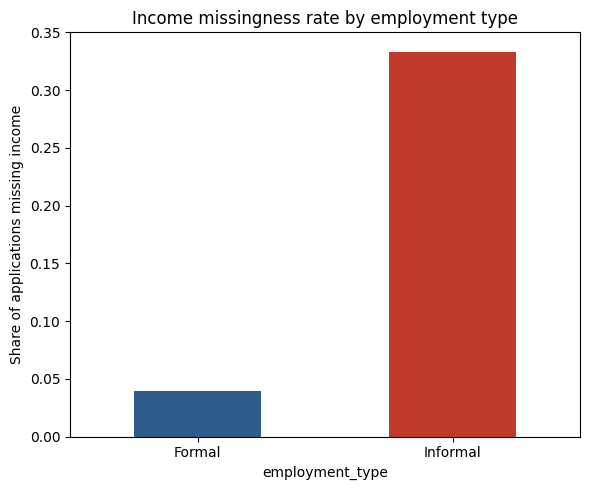

Remaining missing values after grouped-median imputation: 0


In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
missing_by_group["missing_rate"].plot(kind="bar", ax=ax, color=["#2E5C8A", "#C0392B"])
ax.set_ylabel("Share of applications missing income")
ax.set_title("Income missingness rate by employment type")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

# Treatment: grouped-median imputation, consistent with the MAR diagnosis above
applicants_imputed = applicants.copy()
applicants_imputed["monthly_income_php"] = applicants_imputed.groupby("employment_type")["monthly_income_php"] \
    .transform(lambda s: s.fillna(s.median()))

print("Remaining missing values after grouped-median imputation:",
      applicants_imputed["monthly_income_php"].isna().sum())

- The chi-square test rejects independence overwhelmingly: missingness is strongly associated with employment type (roughly 33% of Informal applications are missing income against roughly 4% of Formal ones), which is the signature of MAR rather than MCAR.
- Dropping every incomplete row would have removed Informal applicants disproportionately — shrinking exactly the segment BayaniFund is built to serve — and would have biased any statistic computed afterward toward the Formal-sector income profile.
- Grouped-median imputation instead fills each gap using the typical value for applicants who look like that one, closing the gap without erasing the group difference that caused it.

#### Business Application

- RJ can now report to the credit committee that no applications were discarded for having an incomplete income field, which matters directly for portfolio fairness — an automatic drop-missing rule would have systematically under-represented informal-sector applicants in every downstream statistic and in the training data for the scoring model itself.
- The grouped-median imputation preserves each applicant's record while assigning an income figure consistent with their employment segment, which RJ can defend to both the credit committee and, if needed, a fair-lending review.

### 4. Outlier Detection — IQR Method and Z-Score Method

**Business Hook:** RJ suspects a small number of applications report income that is simply not real — either a typo or a deliberate attempt to inflate an application. Auto-flagging every applicant who earns "a lot more than most" would sweep up genuinely high-earning Formal-sector applicants along with the fabricated entries. RJ needs a method precise enough to separate the two.

#### Intuition & Analogy

Think of outlier detection as airport security screening.

- **IQR (interquartile range) method:** like a metal-detector threshold calibrated to the middle 50% of ordinary travelers — anyone who deviates far enough from that typical range gets pulled aside for a second look. It doesn't accuse anyone of wrongdoing; it just flags anything unusual relative to the bulk of the data, which on a skewed distribution can mean flagging a lot of innocent people who are simply on the legitimate high end.
- **Z-score method:** a more calibrated version of the same idea, measuring how many standard deviations a point sits from the mean — but on skewed data, the mean and standard deviation themselves are stretched by the same extreme values being searched for, so the two methods can disagree about who deserves a second look.

#### Theory — By Hand

- **IQR method.** With $Q_1$ and $Q_3$ as the 25th and 75th percentiles, $IQR = Q_3 - Q_1$, and Tukey's fences:

  $$\text{lower bound} = Q_1 - 1.5 \times IQR, \qquad \text{upper bound} = Q_3 + 1.5 \times IQR$$

  Any value outside these bounds is flagged.

- **Z-score method.** With sample mean $\bar{x}$ and standard deviation $s$:

  $$z_i = \frac{x_i - \bar{x}}{s}$$

  A common convention flags $|z_i| > 3$ on larger samples; on very small samples a slightly looser threshold such as $|z_i| > 2$ is often used since extreme values pull the mean and standard deviation with them.

**Worked example.** Six hypothetical incomes (PHP), sorted: $11{,}000,\ 12{,}500,\ 13{,}000,\ 13{,}800,\ 14{,}200,\ 52{,}000$.

- $Q_1 = 12{,}625$, $Q_3 = 14{,}100$ (linear interpolation), so $IQR = 1{,}475$.
- Bounds: $\text{lower} = 12625 - 1.5(1475) = 10{,}412.5$, $\text{upper} = 14100 + 1.5(1475) = 16{,}312.5$.
- Only $52{,}000$ falls outside $[10{,}412.5,\ 16{,}312.5]$ — flagged by the IQR method.
- Mean $\bar{x} = 19{,}416.67$, standard deviation $s \approx 16{,}001.80$ (sample, $n-1$ divisor); the z-score for the largest value is $z = \dfrac{52000 - 19416.67}{16001.80} \approx 2.04$.
- Using a $|z|>2$ threshold appropriate for this small sample, the same point is flagged by both methods — a reassuring agreement on a clean, small example. As the next cell shows, that agreement breaks down once the full batch is skewed by genuine variation *and* a few fabricated entries at once.

#### By Tool

In [9]:
# Verify the by-hand IQR and z-score results on the six-point worked example
outlier_example = np.array([11000, 12500, 13000, 13800, 14200, 52000.0])

q1_ex, q3_ex = np.percentile(outlier_example, [25, 75])
iqr_ex = q3_ex - q1_ex
lower_ex, upper_ex = q1_ex - 1.5 * iqr_ex, q3_ex + 1.5 * iqr_ex
print(f"By-hand check -- Q1={q1_ex}, Q3={q3_ex}, IQR={iqr_ex}")
print(f"By-hand check -- bounds = [{lower_ex}, {upper_ex}]")
print("By-hand check -- flagged by IQR:", outlier_example[(outlier_example < lower_ex) | (outlier_example > upper_ex)])

z_ex = (outlier_example - outlier_example.mean()) / outlier_example.std(ddof=1)
print("By-hand check -- z-scores:", np.round(z_ex, 2))

By-hand check -- Q1=12625.0, Q3=14100.0, IQR=1475.0
By-hand check -- bounds = [10412.5, 16312.5]
By-hand check -- flagged by IQR: [52000.]
By-hand check -- z-scores: [-0.53 -0.43 -0.4  -0.35 -0.33  2.04]


In [10]:
# Apply both methods to the full, imputed income series
income = applicants_imputed["monthly_income_php"]

q1, q3 = income.quantile(0.25), income.quantile(0.75)
iqr = q3 - q1
lower_bound, upper_bound = q1 - 1.5 * iqr, q3 + 1.5 * iqr

z_scores = (income - income.mean()) / income.std()

iqr_flagged = applicants_imputed.index[(income < lower_bound) | (income > upper_bound)]
z_flagged = applicants_imputed.index[z_scores.abs() > 3]

print(f"IQR bounds: [{lower_bound:,.0f}, {upper_bound:,.0f}]")
print(f"Flagged by IQR method:     {len(iqr_flagged)} applicants")
print(f"Flagged by z-score method (|z|>3): {len(z_flagged)} applicants")
print(f"Flagged by both methods:   {len(set(iqr_flagged) & set(z_flagged))} applicants")

confirmed_anomalies = applicants_imputed.loc[z_flagged]
print("\nApplicants flagged by z-score (the confirmed anomalies):")
print(confirmed_anomalies[["applicant_id", "employment_type", "monthly_income_php"]]
      .sort_values("monthly_income_php", ascending=False))

IQR bounds: [4,188, 27,168]
Flagged by IQR method:     39 applicants
Flagged by z-score method (|z|>3): 6 applicants
Flagged by both methods:   6 applicants

Applicants flagged by z-score (the confirmed anomalies):
    applicant_id employment_type  monthly_income_php
293      BF02500        Informal            396930.0
45       BF02252          Formal            316210.0
12       BF02219        Informal            284720.0
0        BF02207          Formal            165500.0
95       BF02302          Formal            119200.0
44       BF02251          Formal            118100.0


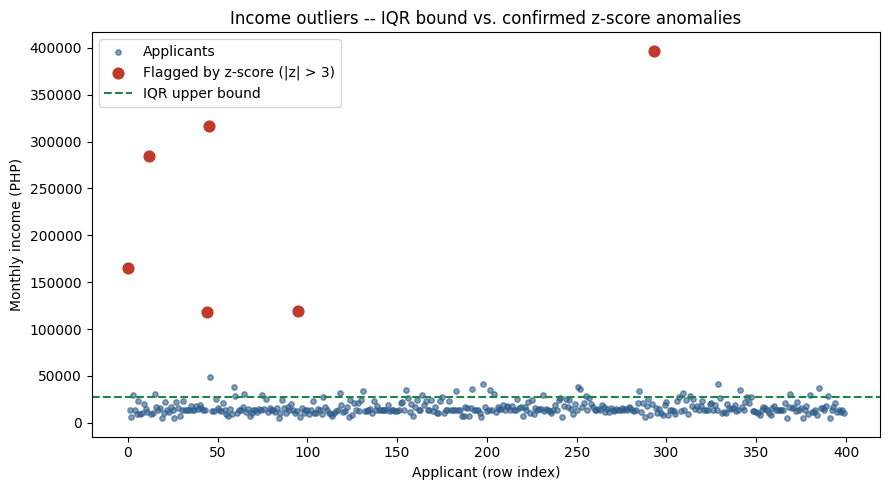

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(range(len(income)), income, s=15, color="#2E5C8A", alpha=0.6, label="Applicants")
ax.scatter(z_flagged, income.loc[z_flagged], s=60, color="#C0392B",
           label="Flagged by z-score (|z| > 3)", zorder=5)
ax.axhline(upper_bound, color="#1E8449", linestyle="--", label="IQR upper bound")
ax.set_xlabel("Applicant (row index)")
ax.set_ylabel("Monthly income (PHP)")
ax.set_title("Income outliers -- IQR bound vs. confirmed z-score anomalies")
ax.legend()
plt.tight_layout()
plt.show()

On this batch the two methods disagree sharply: the IQR method flags 39 applicants, while the z-score method flags only 6.

- The 33 applicants flagged by IQR alone cluster in the PHP 27,000–48,000 range and are disproportionately Formal-sector — these look like genuinely higher-earning applicants sitting in the natural right tail of a skewed distribution, not data errors.
- The 6 applicants flagged by both methods report incomes above PHP 100,000, an order of magnitude beyond anything else in the batch — these match the data-entry slips and fraud attempts planted in the data, and are the ones that warrant action.

This is the central lesson of skewed-data outlier detection: the IQR method, calibrated only to the middle 50% of the data, over-flags on a long right tail, while the z-score method's own mean and standard deviation get dragged by the same extreme points it's trying to catch — so a strict $|z|>3$ threshold on skewed data tends to isolate only the most severe anomalies, which is a feature here, not a bug.

**Treatment:** only the 6 z-score-confirmed anomalies are corrected — each is capped at the IQR upper bound as a conservative, defensible substitute pending manual underwriting review. The 33 IQR-only flags are left untouched, since removing legitimate high earners would itself introduce bias.

#### Business Application

- RJ routes the 6 confirmed anomalies to manual underwriting review rather than auto-rejecting or silently deleting them — some may be genuine typos worth a follow-up call rather than a fraud referral.
- RJ does *not* treat the 33 IQR-only flagged applicants as suspicious: doing so would have penalized BayaniFund's more successful Formal-sector borrowers simply for earning at the legitimate high end of a right-skewed distribution, which is exactly the kind of blanket rule that damages a lender's reputation with good customers.

In [12]:
# Treat only the z-score-confirmed anomalies: cap at the IQR upper bound
applicants_treated = applicants_imputed.copy()
applicants_treated.loc[z_flagged, "monthly_income_php"] = upper_bound

skew_before = stats.skew(income, bias=False)
skew_after = stats.skew(applicants_treated["monthly_income_php"], bias=False)
kurt_before = stats.kurtosis(income, bias=False)
kurt_after = stats.kurtosis(applicants_treated["monthly_income_php"], bias=False)

print(f"Skewness   -- before treatment: {skew_before:.2f}, after treatment: {skew_after:.2f}")
print(f"Excess kurtosis -- before treatment: {kurt_before:.2f}, after treatment: {kurt_after:.2f}")

Skewness   -- before treatment: 9.46, after treatment: 1.37
Excess kurtosis -- before treatment: 99.62, after treatment: 2.18


- Capping only the six confirmed anomalies brings skewness down from roughly 9.5 to roughly 1.4 and excess kurtosis from roughly 100 down to roughly 2 — most of the earlier extreme shape was indeed driven by a handful of corrupted entries, not by income's ordinary skew.
- A skewness of 1.4 is still meaningfully right-skewed, which is expected and appropriate for income data — that residual, honest skew is exactly what Subtopic 5's transformations address.

### 5. Common Transformations — Log, Square Root, and Standardization

**Business Hook:** Income is now free of missing values and confirmed data-entry errors, but it is still right-skewed — a residual property of income itself, not a defect to be corrected away by deleting more data. RJ needs to reshape the variable itself so it behaves well as an input to the credit-scoring model, without discarding any applicants.

#### Intuition & Analogy

A transformation reshapes a variable so it behaves better for analysis, without changing the applicants it describes.

- **Log transform:** works like viewing a cityscape from far above instead of at street level — from the ground, a 100-story skyscraper next to two-story shophouses makes the shophouses look irrelevant by comparison; from high enough above, the *relative* differences in height become comparable again. Taking the log of income compresses large values proportionally more than small ones, pulling in a long right tail without touching the low end much.
- **Square-root transform:** does something similar but more gently — useful for moderate skew or count-like data, but often not strong enough for the kind of skew income typically shows.
- **Standardization** ($z = \frac{x-\mu}{\sigma}$): a different tool entirely — it re-centers a variable to mean 0 and scales it to standard deviation 1, which matters for putting variables measured in different units (income in pesos, months employed in months) onto a comparable scale. Because it only shifts and rescales, it leaves the *shape* of the distribution, including its skewness, completely unchanged.

#### Theory — By Hand

$$\text{log transform: } y_i = \ln(x_i), \qquad \text{square-root transform: } y_i = \sqrt{x_i}, \qquad \text{standardization: } z_i = \frac{x_i - \bar{x}}{s}$$

**Worked example**, four incomes (PHP): $12{,}000,\ 14{,}000,\ 16{,}000,\ 46{,}000$.

- **Log transform:** $\ln(12000) \approx 9.393$, $\ln(14000) \approx 9.547$, $\ln(16000) \approx 9.680$, $\ln(46000) \approx 10.736$ — on the log scale the gap between the largest value and the rest shrinks from a difference of tens of thousands of pesos to a difference of about one log-unit, comparable to the gaps between the other three points.
- **Square-root transform:** $\sqrt{12000}\approx 109.5$, $\sqrt{14000}\approx 118.3$, $\sqrt{16000}\approx 126.5$, $\sqrt{46000}\approx 214.5$ — compressed, but the highest value is still roughly double the others, a milder correction than the log.
- **Standardization:** mean $=22{,}000$, sample standard deviation $s \approx 16{,}083$, giving $z$-values of approximately $-0.62,\ -0.50,\ -0.37,\ 1.49$ — the values are now centered and scaled, but plotted on a number line they retain exactly the same relative spacing, and therefore exactly the same skew, as the original four incomes.

At only four points, sample skewness estimates are unstable, so the by-hand example is meant to show the *mechanics* of each transform rather than a precise before/after skewness comparison — the full-scale result below shows that comparison properly.

#### By Tool

In [13]:
# Verify the by-hand transformation mechanics on the four-point worked example
transform_example = np.array([12000, 14000, 16000, 46000.0])
print("Log:  ", np.round(np.log(transform_example), 3))
print("Sqrt: ", np.round(np.sqrt(transform_example), 1))
te_mean, te_std = transform_example.mean(), transform_example.std(ddof=1)
print("Standardized:", np.round((transform_example - te_mean) / te_std, 2))

Log:   [ 9.393  9.547  9.68  10.736]
Sqrt:  [109.5 118.3 126.5 214.5]
Standardized: [-0.62 -0.5  -0.37  1.49]


In [14]:
# Apply all three transforms to the full, cleaned income series and compare shape
income_clean = applicants_treated["monthly_income_php"]

log_income = np.log(income_clean)
sqrt_income = np.sqrt(income_clean)
standardized_income = (income_clean - income_clean.mean()) / income_clean.std()

shape_summary = pd.DataFrame({
    "transform": ["raw (cleaned)", "log", "square root", "standardized"],
    "skewness": [
        stats.skew(income_clean, bias=False),
        stats.skew(log_income, bias=False),
        stats.skew(sqrt_income, bias=False),
        stats.skew(standardized_income, bias=False),
    ],
})
print(shape_summary.round(3))

shapiro_log = stats.shapiro(log_income)
print(f"\nShapiro-Wilk on log-income: W = {shapiro_log.statistic:.4f}, p = {shapiro_log.pvalue:.2e}")

       transform  skewness
0  raw (cleaned)     1.368
1            log     0.113
2    square root     0.772
3   standardized     1.368

Shapiro-Wilk on log-income: W = 0.9713, p = 4.28e-07


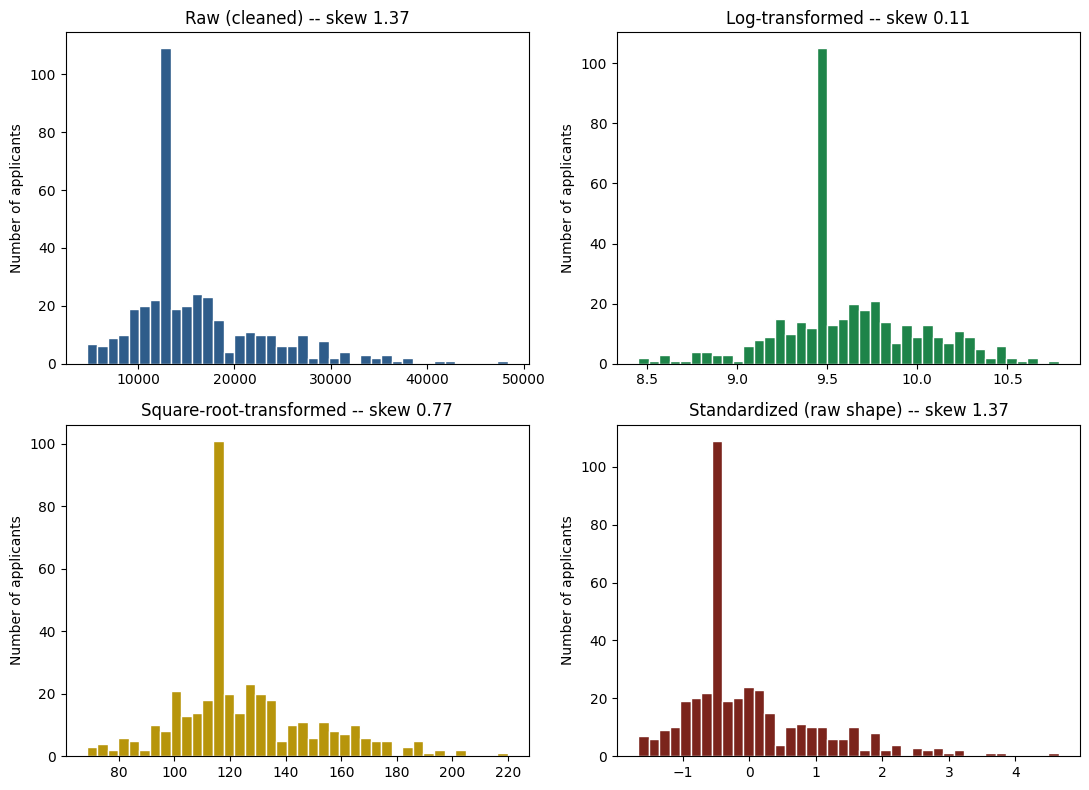

,applicant_id,monthly_income_php,income_feature_for_model
0,BF02207,27167.5,1.499034
1,BF02208,13065.0,-0.341005
2,BF02209,6420.0,-2.126840
3,BF02210,29440.0,1.700945
4,BF02211,13065.0,-0.341005


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

axes[0, 0].hist(income_clean, bins=40, color="#2E5C8A", edgecolor="white")
axes[0, 0].set_title(f"Raw (cleaned) -- skew {stats.skew(income_clean, bias=False):.2f}")

axes[0, 1].hist(log_income, bins=40, color="#1E8449", edgecolor="white")
axes[0, 1].set_title(f"Log-transformed -- skew {stats.skew(log_income, bias=False):.2f}")

axes[1, 0].hist(sqrt_income, bins=40, color="#B7950B", edgecolor="white")
axes[1, 0].set_title(f"Square-root-transformed -- skew {stats.skew(sqrt_income, bias=False):.2f}")

axes[1, 1].hist(standardized_income, bins=40, color="#7B241C", edgecolor="white")
axes[1, 1].set_title(f"Standardized (raw shape) -- skew {stats.skew(standardized_income, bias=False):.2f}")

for ax in axes.flat:
    ax.set_ylabel("Number of applicants")
plt.tight_layout()
plt.show()

# Model-ready feature: log first to fix shape, then standardize for scale
model_ready_income = (log_income - log_income.mean()) / log_income.std()
applicants_treated["income_feature_for_model"] = model_ready_income
applicants_treated[["applicant_id", "monthly_income_php", "income_feature_for_model"]].head()

- The log transform is the clear winner for this variable: skewness drops from roughly 1.4 on the cleaned raw scale to close to 0 on the log scale, and the histogram visibly loses its long right tail.
- The square-root transform helps but not nearly as much, consistent with it being a gentler correction meant for milder skew.
- Standardization, as expected from the theory, leaves skewness completely unchanged — it recenters and rescales the variable but does not touch its shape, confirming that shape correction and scale correction are two different jobs that need two different tools.
- Shapiro-Wilk on the log-transformed income is still statistically significant given the large sample size (this is common with n in the hundreds), even though the histogram and skewness value show real, practical improvement — a reminder that statistical significance and practical significance are not the same question.

#### Business Application

- RJ builds the final model-ready income feature by log-transforming income to fix its shape and then standardizing that log-scale value to mean 0 and standard deviation 1, putting it on a comparable footing with the model's other numeric predictors (such as months employed).
- This two-step choice is deliberate and defensible in the underwriting documentation: the log step is what corrects skewness, and the standardization step is what makes the scale comparable across features — collapsing them into one step (standardizing the raw income) would have delivered a scaled variable that was still just as skewed as before.

## Key Takeaways

**Distribution shape**
- Right-skewed data (skewness > 0) has a long tail toward high values; the mean is pulled above the median.
- Excess kurtosis above 0 signals heavier tails and more extreme values than a normal distribution predicts.
- Extremely large skewness/kurtosis values (far beyond what the shape of the underlying process would suggest) are themselves a diagnostic clue pointing toward data-quality issues.

**Checking for normality**
- Q-Q plots show *where* a distribution departs from normal; skewness/kurtosis z-scores and Shapiro-Wilk give a numeric, decision-ready confirmation.
- With large samples, formal tests can be statistically significant even for departures that are practically minor — always pair the test with the visual and the effect size.

**Missing data**
- MCAR: missingness unrelated to anything observed or unobserved — generally safe to drop.
- MAR: missingness predictable from an observed variable — safe to impute using that variable (e.g., grouped medians).
- MNAR: missingness tied to the unobserved value itself — resistant to both dropping and standard imputation.
- A chi-square test of missingness against a candidate grouping variable is a quick, defensible way to distinguish MCAR from MAR.

**Outlier detection**
- The IQR method (Tukey's fences) is calibrated to the middle 50% of the data and over-flags on skewed distributions.
- The z-score method uses the mean and standard deviation, which are themselves distorted by the extreme values being searched for.
- Disagreement between the two methods is informative: points flagged by both warrant real scrutiny; points flagged only by IQR may just be the legitimate tail of a skewed variable.

**Transformations**
- Log and square-root transforms correct skewness by compressing large values proportionally more than small ones; log is the stronger correction of the two.
- Standardization changes scale (mean 0, standard deviation 1) but never changes shape — skewness before and after standardization is identical.
- Shape correction and scale correction are separate steps and are often both needed, in that order, before a variable is model-ready.

## References

Field, A. (2018). *Discovering statistics using IBM SPSS statistics* (5th ed.). SAGE Publications.

Little, R. J. A., & Rubin, D. B. (2019). *Statistical analysis with missing data* (3rd ed.). John Wiley & Sons.

NIST/SEMATECH. (2012). *e-Handbook of statistical methods.* National Institute of Standards and Technology. https://www.itl.nist.gov/div898/handbook/

Tabachnick, B. G., & Fidell, L. S. (2019). *Using multivariate statistics* (7th ed.). Pearson.

Tukey, J. W. (1977). *Exploratory data analysis.* Addison-Wesley.